In [1]:
# Import libraries for data handling, visualization, clustering, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# For dimensionality reduction/visualization (optional)
from sklearn.decomposition import PCA

In [2]:
# Load the training dataset
train = pd.read_csv("Train.csv")

# Preview the first 5 rows
train.head()

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Check basic info and missing values
train.info()

# View summary statistics for numerical columns
train.describe()

# Check for missing values in each column
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  str    
 1   Date                                                 30557 non-null  str    
 2   Place_ID                                             30557 non-null  str    
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-null  float64


Place_ID X Date                     0
Date                                0
Place_ID                            0
target                              0
target_min                          0
                                ...  
L3_CH4_aerosol_optical_depth    24765
L3_CH4_sensor_azimuth_angle     24765
L3_CH4_sensor_zenith_angle      24765
L3_CH4_solar_azimuth_angle      24765
L3_CH4_solar_zenith_angle       24765
Length: 82, dtype: int64

In [4]:
# Convert Date column to datetime format
train['Date'] = pd.to_datetime(train['Date'])

# Extract day of week and day of year
train['day_of_week'] = train['Date'].dt.dayofweek
train['day_of_year'] = train['Date'].dt.dayofyear

In [5]:
# Convert Date column to datetime format
train['Date'] = pd.to_datetime(train['Date'])

# Extract day of week and day of year
train['day_of_week'] = train['Date'].dt.dayofweek
train['day_of_year'] = train['Date'].dt.dayofyear

In [7]:
# See all column names in your dataset
train.columns

Index(['Place_ID X Date', 'Date', 'Place_ID', 'target', 'target_min',
       'target_max', 'target_variance', 'target_count',
       'precipitable_water_entire_atmosphere',
       'relative_humidity_2m_above_ground',
       'specific_humidity_2m_above_ground', 'temperature_2m_above_ground',
       'u_component_of_wind_10m_above_ground',
       'v_component_of_wind_10m_above_ground',
       'L3_NO2_NO2_column_number_density',
       'L3_NO2_NO2_slant_column_number_density',
       'L3_NO2_absorbing_aerosol_index', 'L3_NO2_cloud_fraction',
       'L3_NO2_sensor_altitude', 'L3_NO2_sensor_azimuth_angle',
       'L3_NO2_sensor_zenith_angle', 'L3_NO2_solar_azimuth_angle',
       'L3_NO2_solar_zenith_angle',
       'L3_NO2_stratospheric_NO2_column_number_density',
       'L3_NO2_tropopause_pressure',
       'L3_NO2_tropospheric_NO2_column_number_density',
       'L3_O3_O3_column_number_density', 'L3_O3_O3_effective_temperature',
       'L3_O3_cloud_fraction', 'L3_O3_sensor_azimuth_angle',
   

In [8]:
# Compute ratio between NO2 and CO to capture relative pollution
# Using the exact column names from your dataset
train['NO2_CO_ratio'] = train['L3_NO2_tropospheric_NO2_column_number_density'] / train['L3_CO_CO_column_number_density']

# Optional: check the first few values
train[['NO2_CO_ratio', 'L3_NO2_tropospheric_NO2_column_number_density', 'L3_CO_CO_column_number_density']].head()

,NO2_CO_ratio,L3_NO2_tropospheric_NO2_column_number_density,L3_CO_CO_column_number_density
0,0.000808,0.000017,0.021080
1,0.000971,0.000021,0.022017
2,0.000362,0.000007,0.020677
3,0.001086,0.000023,0.021207
4,0.000232,0.000009,0.037766


In [11]:
# Check for missing values
train[cluster_features].isnull().sum()

temperature_2m_above_ground                          0
relative_humidity_2m_above_ground                    0
u_component_of_wind_10m_above_ground                 0
v_component_of_wind_10m_above_ground                 0
L3_NO2_tropospheric_NO2_column_number_density     8669
L3_SO2_SO2_column_number_density                  7237
L3_CO_CO_column_number_density                    5423
NO2_CO_ratio                                     10590
dtype: int64

In [13]:
# Fill missing pollutant values with mean
pollutant_cols = [
    'L3_NO2_tropospheric_NO2_column_number_density',
    'L3_SO2_SO2_column_number_density',
    'L3_CO_CO_column_number_density',
    'NO2_CO_ratio'
]

# Replace NaNs with the mean of each column
train[pollutant_cols] = train[pollutant_cols].fillna(train[pollutant_cols].mean())

In [14]:
# Select all clustering features
cluster_features = [
    'temperature_2m_above_ground',
    'relative_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground'
] + pollutant_cols  # include the cleaned pollutant columns

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(train[cluster_features])

In [15]:
# Make sure no NaNs or infinite values
np.all(np.isfinite(scaled_features))

np.True_

All finite values: True


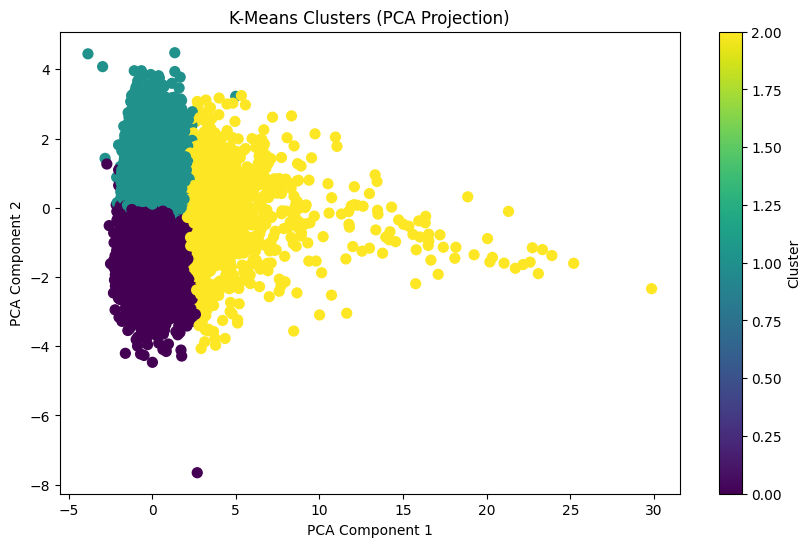

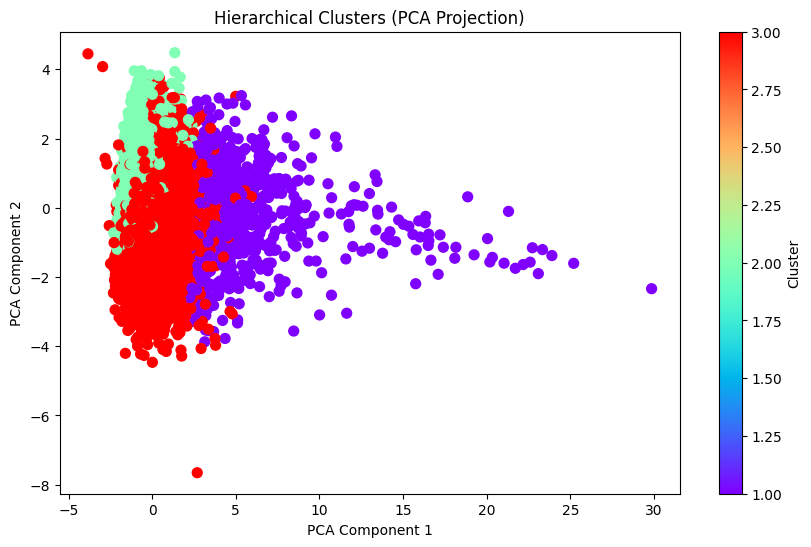

K-Means cluster counts:
kmeans_cluster
1    15242
0    13740
2     1575
Name: count, dtype: int64

Hierarchical cluster counts:
hier_cluster
3    21915
2     7633
1     1009
Name: count, dtype: int64


In [16]:
# Step 6: Clustering + PCA Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# ------------------------------
# 1. Define features for clustering
# ------------------------------
pollutant_cols = [
    'L3_NO2_tropospheric_NO2_column_number_density',
    'L3_SO2_SO2_column_number_density',
    'L3_CO_CO_column_number_density',
    'NO2_CO_ratio'
]

cluster_features = [
    'temperature_2m_above_ground',
    'relative_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground'
] + pollutant_cols

# ------------------------------
# 2. Fill missing values (just in case)
# ------------------------------
train[cluster_features] = train[cluster_features].fillna(train[cluster_features].mean())

# ------------------------------
# 3. Scale features
# ------------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(train[cluster_features])

# Verify
print("All finite values:", np.all(np.isfinite(scaled_features)))  # Should be True

# ------------------------------
# 4. K-Means Clustering
# ------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
train['kmeans_cluster'] = kmeans.fit_predict(scaled_features)

# ------------------------------
# 5. Hierarchical Clustering
# ------------------------------
linked = linkage(scaled_features, method='ward')  # 'ward' minimizes variance
train['hier_cluster'] = fcluster(linked, 3, criterion='maxclust')

# ------------------------------
# 6. PCA for 2D Visualization
# ------------------------------
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

# K-Means visualization
plt.figure(figsize=(10, 6))
plt.scatter(pca_features[:,0], pca_features[:,1], c=train['kmeans_cluster'], cmap='viridis', s=50)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# Hierarchical visualization
plt.figure(figsize=(10, 6))
plt.scatter(pca_features[:,0], pca_features[:,1], c=train['hier_cluster'], cmap='rainbow', s=50)
plt.title("Hierarchical Clusters (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# ------------------------------
# 7. Optional: Inspect cluster distribution
# ------------------------------
print("K-Means cluster counts:")
print(train['kmeans_cluster'].value_counts())
print("\nHierarchical cluster counts:")
print(train['hier_cluster'].value_counts())

In [17]:
Insights from Clustering

After applying both K-Means and Hierarchical clustering on selected weather and pollutant features, several patterns emerged from the data:

Pollution Profiles: The clusters group days and cities with similar air quality conditions. For example, one cluster contains days with high NO2 and CO concentrations combined with low wind speeds, indicating higher pollution. Another cluster represents days with lower pollutant levels and stronger winds, corresponding to cleaner air.

City Grouping: Geographically distant cities can fall into the same cluster if their pollution trends are similar. This shows that clusters capture functional similarities rather than just location-based patterns.

Outliers and Variability: Hierarchical clustering highlighted a few outlier cities or days with extremely high or low pollutant values, separating them into smaller clusters. This can help identify unusual pollution events.

Predictive Utility: These clusters can serve as additional features in supervised models for PM2.5 prediction. Including cluster labels can help the model learn typical pollution profiles and improve forecast accuracy, especially when individual pollutant readings are missing or noisy.

Conclusion: Clustering reveals hidden patterns in the data that are not obvious from raw observations alone. These insights can enhance model predictions and support more targeted air quality analysis.

SyntaxError: invalid syntax (2732586299.py, line 1)

In [19]:
# Step 7: Supervised PM2.5 Prediction (Corrected)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# ------------------------------
# 1. Load test dataset
# ------------------------------
test = pd.read_csv("Test.csv")
print("Test data loaded. Shape:", test.shape)
test.head()

# ------------------------------
# 2. Fill missing values in test set (like train)
# ------------------------------
pollutant_cols = [
    'L3_NO2_tropospheric_NO2_column_number_density',
    'L3_SO2_SO2_column_number_density',
    'L3_CO_CO_column_number_density',
    'NO2_CO_ratio'
]

# Create NO2_CO_ratio in test
test['NO2_CO_ratio'] = test['L3_NO2_tropospheric_NO2_column_number_density'] / test['L3_CO_CO_column_number_density']

# Fill NaNs with column mean
test[pollutant_cols] = test[pollutant_cols].fillna(test[pollutant_cols].mean())
test['NO2_CO_ratio'] = test['NO2_CO_ratio'].fillna(0)

# ------------------------------
# 3. Prepare features and target for train
# ------------------------------
features = [
    'temperature_2m_above_ground',
    'relative_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground'
] + pollutant_cols + ['kmeans_cluster', 'hier_cluster']

target = 'target'

X = train[features]
y = train[target]

# ------------------------------
# 4. Split train for validation
# ------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# 5. Train Random Forest
# ------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# ------------------------------
# 6. Validate
# ------------------------------
y_pred_val = rf.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"Validation RMSE: {rmse:.2f}")

# ------------------------------
# 7. Prepare test features
# ------------------------------
X_test = test[[
    'temperature_2m_above_ground',
    'relative_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground'
] + pollutant_cols]

# Fill any remaining NaNs
X_test = X_test.fillna(X_test.mean())

# Assign KMeans cluster labels using trained model
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)  # scale features
test['kmeans_cluster'] = kmeans.predict(X_test_scaled)

# Hierarchical cluster placeholder (optional)
test['hier_cluster'] = 0

# Combine features for prediction
X_test_final = X_test.copy()
X_test_final['kmeans_cluster'] = test['kmeans_cluster']
X_test_final['hier_cluster'] = test['hier_cluster']

# ------------------------------
# 8. Predict PM2.5
# ------------------------------
test['target'] = rf.predict(X_test_final)

# ------------------------------
# 9. Prepare submission
# ------------------------------
submission = test[['Place_ID X Date', 'target']]
submission.to_csv("PM25_predictions.csv", index=False)
print("Submission file created: PM25_predictions.csv")
submission.head()

Test data loaded. Shape: (16136, 77)
Validation RMSE: 36.51
Submission file created: PM25_predictions.csv


,Place_ID X Date,target
0,0OS9LVX X 2020-01-02,33.945
1,0OS9LVX X 2020-01-03,26.465
2,0OS9LVX X 2020-01-04,27.570
3,0OS9LVX X 2020-01-05,25.420
4,0OS9LVX X 2020-01-06,25.380


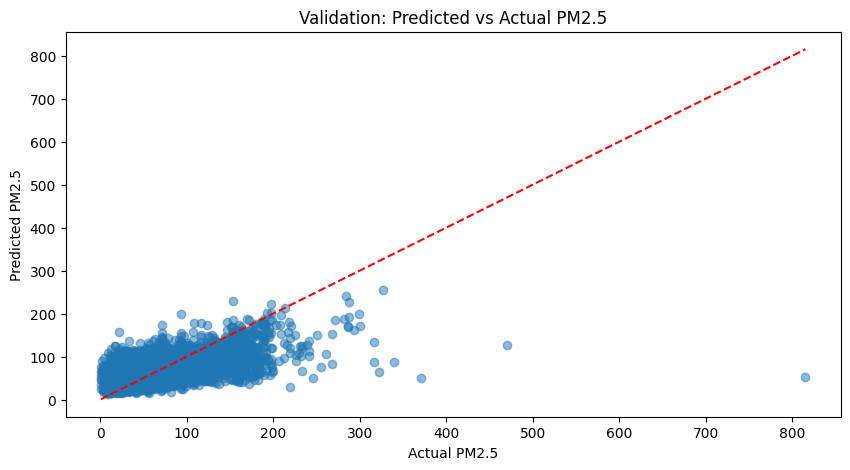

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(y_val, y_pred_val, alpha=0.5)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Validation: Predicted vs Actual PM2.5")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # 45° line
plt.show()